In [2]:
import os
import sys
import pandas as pd
sys.path.append('..')
from unstructured.staging.base import elements_from_json
from langchain_core.documents import Document
from langchain.vectorstores import FAISS
from langchain.embeddings import HuggingFaceEmbeddings
from openai import OpenAI
from sentence_transformers import SentenceTransformer, util
import numpy as np

import torch
from bert_score import BERTScorer

import matplotlib.pyplot as plt
import seaborn as sns

from src.utils.paths import get_project_path

In [116]:
data = pd.read_excel("/Users/vinavolo/Documents/Project/SciNanoAI/notebooks/30_val_DEL.xlsx").drop(columns=["Unnamed: 0"])

In [128]:
# generated = data["RAG_Ответ"].replace(np.NaN, "Нет")
# references = data['Правильный ответ\xa0'].replace(np.NaN, "Нет")

# references = [ref.replace("\n", " ").strip() for ref in references]
# generated = [pred.replace("\n", " ").strip() for pred in generated]



generated = data['google/gemini-2.5-flash-lite'].values
references = data['Модельный ответ'].values

references = [ref.replace("\n", " ").strip() for ref in references]
generated = [pred.replace("\n", " ").strip() for pred in generated]

In [114]:
dd = {}

for COL in data.columns[3:]:
    generated = data[COL].values
    references = data['Модельный ответ'].values

    references = [ref.replace("\n", " ").strip() for ref in references]
    generated = [pred.replace("\n", " ").strip() for pred in generated]

    matches = []

    for i in range(len(generated)):
        pdf_files = [w for w in generated[i].split(" ") if ".pdf" in w]
        cleaned_files = [w.strip("[]' ,.") for w in pdf_files]

        # проверяем, есть ли совпадение с эталоном
        if data.Статья.iloc[i] in cleaned_files:
            matches.append(1)   # совпало
        else:
            matches.append(0)   # не совпало

    # добавляем колонку в результирующий словарь
    # dd[COL] = [np.mean(matches)]
    dd[COL] = matches
    
# преобразуем словарь в DataFrame
result_df = pd.DataFrame(dd)

In [115]:
result_df

,openai/gpt-4,openai/gpt-4o-mini,openai/gpt-4o-2024-11-20,meta-llama/llama-3.1-405b-instruct,openai/gpt-5-chat,openai/gpt-oss-120b,google/gemini-2.5-flash-lite
0,1,1,1,1,1,0,1
1,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0


In [119]:
data.columns

Index(['Запрос', 'Модельный ответ', 'Статья', 'openai/gpt-4',
       'openai/gpt-4o-mini', 'openai/gpt-4o-2024-11-20',
       'meta-llama/llama-3.1-405b-instruct', 'openai/gpt-5-chat',
       'openai/gpt-oss-120b', 'google/gemini-2.5-flash-lite'],
      dtype='object')

In [150]:
generated = data["google/gemini-2.5-flash-lite"].replace(np.NaN, "Нет")
references = data['Модельный ответ'].replace(np.NaN, "Нет")

references = [ref.replace("\n", " ").strip() for ref in references]
generated = [pred.replace("\n", " ").strip() for pred in generated]

## Accuracy

In [151]:
# def classify_responses(data_q, data_c, data_m):

#     classifications = []

#     openai_api_key = os.environ["OPENAI_API_KEY"]
#     openai_api_base = os.environ["OPENAI_API_BASE"]
    

#     for question, correct_answer, model_answer in zip(data_q, data_c, data_m):
#         prompt = f"Вопрос: {question}\n\n" \
#                  f"Эталонный ответ: {correct_answer}\n\n" \
#                  f"Ответ модели: {model_answer}\n\n" \
#                  "Оцени, правильно ли ответила модель на поставленный вопрос. Оценивай не точное 100% совпадение ответа с эталонным, а скорее правильность ответа на поставленный вопрос по сравнению с эталонным (1 - правильно, 0 - неправильно)." \
#                  " Ответь только цифрой."

#         try:
#             openai_client = OpenAI(
#                 base_url=openai_api_base
#                 )

#             response = openai_client.chat.completions.create(
#                 model="openai/gpt-4o-2024-11-20",
#                 messages=[{"role": "user", "content": prompt}],
#                 temperature=0.2,
#                 max_tokens=4096
#             )
#             classification = int(response.choices[0].message.content.strip())
#             classifications.append(classification)

#         except Exception as e:
#             print(f"Ошибка: {e}")
#             classifications.append(0)  # Если ошибка, считаем, что ответ неверный

#     return classifications

# ans = classify_responses(data["Запрос"], references, generated)
# np.mean(ans)

## BERTScore

In [152]:
scorer = BERTScorer(model_type="bert-base-multilingual-cased", lang="ru")
P, R, F1 = scorer.score(generated, references)
print(torch.mean(F1))

tensor(0.6699)


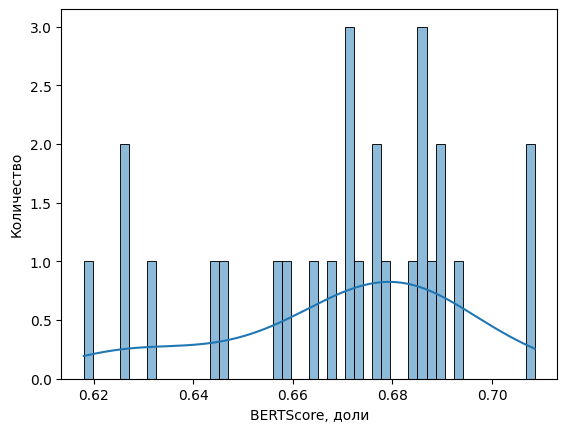

In [153]:
sns.histplot(F1.detach().cpu().numpy(), bins=50, kde=True)
plt.xlabel('BERTScore, доли')
plt.ylabel("Количество")
plt.show()

## Cosin Sim

In [154]:
model = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2')

def calculate_cosine_similarity(references, generated):

    model = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2')

    cosine_scores = []
    for ref, gen in zip(references, generated):
        ref_embedding = model.encode(ref, convert_to_tensor=True)
        gen_embedding = model.encode(gen, convert_to_tensor=True)
        cosine_score = util.pytorch_cos_sim(ref_embedding, gen_embedding).item()
        cosine_scores.append(cosine_score)
    return cosine_scores

cosine_scores = calculate_cosine_similarity(references, generated)
print("Cosine Similarity Scores:", np.mean(cosine_scores))


Cosine Similarity Scores: 0.7832863330841064


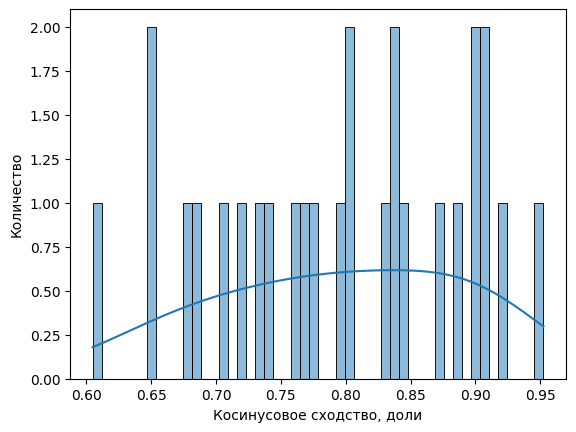

In [145]:
sns.histplot(cosine_scores, bins=50, kde=True)
plt.xlabel('Косинусовое сходство, доли')
plt.ylabel("Количество")
plt.show()